<h1 align="center">Cost Function Regularization</h1>

Regularization in ML is a technique that is used to control overfitting in a model.
The regularization technique is directly implemented in the cost function of a model and there exist only 3 variations of it. 

The very basic concept of work for the regularization technique is to `prevent and punish the cost function as it tries reaching 0 cost`. 

We do this in order to not have `overfitting` which captures the noise of a dataset, which then causes it to perform on new `unseen data`.


<p align="center">
<img src="../images/overfit.png" width="300px">
</p>

<h5>The 3 types of regularization: </h5>

**L1 Regularization (Lasso)** — adds a penalty proportional to the absolute size of the weights, encouraging some weights to shrink all the way to zero:
$$J(\mathbf{w}, b) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)^2 + \frac{\lambda}{m}\sum_{j=1}^{n}\left|w_j\right|$$

Where:
* $\lambda$ (lambda) is the regularization paramater
* $n$ is the number of weights 
* $w_j$ is the $j$-th weight 

**L2 Regularization (Ridge)** — adds a penalty proportional to the squared size of the weights, shrinking all of them smoothly toward zero without necessarily eliminating any:
$$J(\mathbf{w}, b) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)^2 + \frac{\lambda}{2m}\sum_{j=1}^{n}w_j^2$$

Where:
* $\lambda$ (lambda) is the regularization paramater
* $n$ is the number of weights (same polynomial coefficients as above)
* $w_j^2$ penalizes large weights more aggressively than small ones, since the penalty grows quadratically

**Elastic Net Regularization** — combines both penalties techniques, letting you blend Lasso's(L1) "zero out some weights" behavior with Ridge's(L2) "shrink everything" behavior:
$$J(\mathbf{w}, b) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)^2 + \frac{\lambda}{m}\left[r\sum_{j=1}^{n}\left|w_j\right| + \frac{(1-r)}{2}\sum_{j=1}^{n}w_j^2\right]$$

Where:
* $\lambda$ (lambda) is the overall regularization strength
* $r$ (the mix ratio, between 0 and 1) controls the blend — $r=1$ reduces to only L1, $r=0$ reduces to only L2
* $n$ is the number of weights(features)
* $w_j$ and $w_j^2$ are the L1 and L2 penalty terms respectively, weighted by $r$ and $(1-r)$


In [150]:
"""
    Dataset of 50 samples, each with 2 features (x1, x2) and a target value (y).
    This is a synthetic dataset generated for the purpose of training a simple polynomial regression model.
    That is in the form of: y = b + W1x1 - W2x2 + W3x1² - W4x1x2
    
    The dataset for now has only 2 features, 
    but we will extend it to 2 more features equalling total 4 in order to get a polynomial regression model.
"""

import numpy as np

x1 = [0.132, 0.462, -1.066, 0.755, -0.834, 0.058, 0.856, -1.433, -0.527, 1.119, 1.034, 0.115, 1.1, 1.349, 0.979, 1.062, -1.204, 0.454, 0.611, 0.331, 0.899, -1.396, 0.811, 0.695, -0.721, -0.729, 0.397, -0.464, 0.89, -0.162, 0.848, 1.471, -0.599, -1.071, 1.204, 0.125, 1.424, 0.41, 1.482, 0.138, 0.079, -1.094, -0.433, -1.421, -1.019, 0.737, -1.409, -0.4, 1.087, 0.578]
x2 = [0.573, -0.934, -0.174, 0.245, 1.469, -0.888, -0.757, -0.713, 0.751, -0.129, -1.329, 0.026, -0.864, 0.896, -0.608, -1.417, 0.28, 1.032, -0.357, 0.75, 0.033, 0.123, 1.378, 0.912, -1.403, 0.628, -0.105, 1.343, -0.836, -0.699, -1.256, -0.214, -1.173, 0.401, 0.909, 0.59, 0.799, -0.473, 1.038, -0.214, 0.972, 0.379, -1.07, -1.265, -1.445, -1.3, -0.124, -1.16, -1.417, 0.765]
y  = [11.093, 2.048, -10.05, -7.036, -14.602, -8.207, 4.434, 10.418, -1.358, 8.696, 8.159, 3.255, 7.171, 4.527, 9.894, 2.076, 7.851, 7.853, 4.068, 7.355, 1.332, -1.165, 3.59, 2.048, 0.984, -2.674, 0.785, 6.22, -4.463, 5.81, 6.413, 12.954, 6.659, -15.077, 8.455, 4.288, 6.241, 1.981, 10.954, 1.153, 12.677, 5.033, 16.522, -1.537, -7.104, 11.734, 7.382, 4.079, 0.018, 0.435]

y = np.array(y).reshape(-1, 1)

In [151]:
"""
    Feature Engineering: Create polynomial features from the original features (x1, x2).
    We will create two additional features:
    - x1_squared: the square of the first feature (x1^2)
    - x1_x2: the product of the first and second features (x1 * x2)
"""

X_poly = np.column_stack((x1, x2, np.array(x1)**2, np.array(x1)*np.array(x2)))

print("Polynomial Features (X_poly): ")
print(X_poly)

Polynomial Features (X_poly): 
[[ 0.132     0.573     0.017424  0.075636]
 [ 0.462    -0.934     0.213444 -0.431508]
 [-1.066    -0.174     1.136356  0.185484]
 [ 0.755     0.245     0.570025  0.184975]
 [-0.834     1.469     0.695556 -1.225146]
 [ 0.058    -0.888     0.003364 -0.051504]
 [ 0.856    -0.757     0.732736 -0.647992]
 [-1.433    -0.713     2.053489  1.021729]
 [-0.527     0.751     0.277729 -0.395777]
 [ 1.119    -0.129     1.252161 -0.144351]
 [ 1.034    -1.329     1.069156 -1.374186]
 [ 0.115     0.026     0.013225  0.00299 ]
 [ 1.1      -0.864     1.21     -0.9504  ]
 [ 1.349     0.896     1.819801  1.208704]
 [ 0.979    -0.608     0.958441 -0.595232]
 [ 1.062    -1.417     1.127844 -1.504854]
 [-1.204     0.28      1.449616 -0.33712 ]
 [ 0.454     1.032     0.206116  0.468528]
 [ 0.611    -0.357     0.373321 -0.218127]
 [ 0.331     0.75      0.109561  0.24825 ]
 [ 0.899     0.033     0.808201  0.029667]
 [-1.396     0.123     1.948816 -0.171708]
 [ 0.811     1.378     

In [152]:
""" Splitting Train and Test Data: We will split the dataset into training and testing sets.
    - Training set: 80% of the data (40 samples)
    - Testing set: 20% of the data (10 samples)
    """
    
X_train = X_poly[:40]
y_train = y[:40]
X_test = X_poly[40:]
y_test = y[40:]


"""
    Polynomial Regression Model
    
    We only do a forward pass through the model, which is a linear combination of the input features and the weights, plus a bias term.
    The features and weights are represented as matrices, and the bias is a scalar.
    This is why we dont have other variables beacuse of matrix multiplication and the bias term is added to each sample in the batch.
    Matrix Multiplication is used to compute the dot product of the input features and the weights, 
    which results in a vector of predictions for each sample in the batch.
    
    Thus as output we get a vector in the shape of (n_samples, 1) which is the predicted values for each sample in the batch.
"""

def polynomial_regression(X, W, b):
    
    return np.dot(X, W) + b

In [153]:
"""
    Cost Function Implementation with L1,L2 and Elastic Net Regularization:
    We will implement the Mean Squared Error (MSE) cost function with the regularization terms.
    The cost function will take the:
    - True target values (y_true)
    - Predicted target values (y_pred)
    - Weights (W)
    - Bias (b)
    - Regularization parameter lambda
    
    We will implement all three regularization techniques: L1, L2 and Elastic Net Regularization, as seperate functions, 
    which will be used to compute the cost during training, and used to see the difference between the three regularization techniques.
"""


def mse_L1(y_true, X, W, b, lambda_L1):
    """
    Mean Squared Error (MSE) with L1 Regularization
    """
    y_pred = polynomial_regression(X, W, b)
    mse = np.mean((y_true - y_pred) ** 2)
    l1_penalty = lambda_L1 * np.sum(np.abs(W))
    
    print("MSE(L1): ", mse + l1_penalty)
    
    return mse + l1_penalty

def mse_L2(y_true, X, W, b, lambda_L2):
    """
    Mean Squared Error (MSE) with L2 Regularization
    """
    y_pred = polynomial_regression(X, W, b)
    mse = np.mean((y_true - y_pred) ** 2)
    l2_penalty = lambda_L2 * np.sum(W ** 2)
    
    print("MSE(L2): ", mse + l2_penalty)
    
    return mse + l2_penalty

def mse_elastic_net(y_true, X, W, b, lambda_total, ratio):
    """
    Mean Squared Error (MSE) with Elastic Net Regularization
    """
    y_pred = polynomial_regression(X, W, b)
    mse = np.mean((y_true - y_pred) ** 2)
    l1_penalty = lambda_total * ratio * np.sum(np.abs(W))
    l2_penalty = lambda_total * (1 - ratio) * np.sum(W ** 2)
    
    print("MSE(Elastic Net): ", mse + l1_penalty + l2_penalty)
    
    return mse + l1_penalty + l2_penalty

In [154]:
"""
    Gradient Descent Implementation for Polynomial Regression with Regularization:
    We will implement the gradient descent algorithm to optimize the weights and bias of the polynomial regression model
    Implementing the derivatives of the cost function with respect to the weights and bias, and updating them iteratively.

"""


# Gradient Descent Implementaiton with L1 only
def gradient_descent_L1(X, y, W, b, learning_rate, num_iterations, lambda_L1):
    """
    Proximal Gradient Descent Implementation for Polynomial Regression with L1 Regularization
    This function performs gradient descent optimization for a polynomial regression model with L1 regularization.
    Proximal is used beacuse L1 regularization is not differentiable at zero, so we use a proximal operator to handle the non-differentiability.
    The proximal operator for L1 regularization is the soft-thresholding operator, which shrinks the weights towards zero by a certain amount (the regularization parameter).
    The function takes the following parameters:
    - X: Input features (numpy array of shape (n_samples, n_features
    - y: True target values (numpy array of shape (n_samples, 1))
    - W: Weights (numpy array of shape (n_features, 1))
    - b: Bias (scalar)
    - learning_rate: Learning rate for gradient descent (float)
    - num_iterations: Number of iterations for gradient descent (int)
    - lambda_L1: Regularization parameter for L1 regularization (float)
    The function returns the optimized weights and bias after performing gradient descent.
    """
    m = len(y)
    for i in range(num_iterations):
        y_pred = polynomial_regression(X, W, b)
        
        dW_base = (2/m) * np.dot(X.T, (y_pred - y))
        db = (2/m) * np.sum(y_pred - y)
        
        W = W - learning_rate * dW_base
        b = b - learning_rate * db
        
        #Proximal Step (Soft-Thresholding) to enforce L1 sparsity
        penalty = learning_rate * lambda_L1
        W = np.sign(W) * np.maximum(0, np.abs(W) - penalty)
        
        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {mse_L1(y, X, W, b, lambda_L1)}")
    return W, b


def gradient_descent_L2(X, y, W, b, learning_rate, num_iterations, lambda_L2):
    """
    Gradient Descent Implementation for Polynomial Regression with L2 Regularization
    This function performs gradient descent optimization for a polynomial regression model with L2 regularization.
    The function takes the following parameters:
    - X: Input features (numpy array of shape (n_samples, n_features))
    - y: True target values (numpy array of shape (n_samples, 1))
    - W: Weights (numpy array of shape (n_features, 1))
    - b: Bias (scalar)
    - learning_rate: Learning rate for gradient descent (float)
    - num_iterations: Number of iterations for gradient descent (int)
    - lambda_L2: Regularization parameter for L2 regularization (float)
    The function returns the optimized weights and bias after performing gradient descent.
    """
    m = len(y)
    for i in range(num_iterations):
        y_pred = polynomial_regression(X, W, b)
        
        dW_base = (2/m) * np.dot(X.T, (y_pred - y))
        db = (2/m) * np.sum(y_pred - y)
        
        # Add L2 regularization term to the weight update
        dW = dW_base + 2 * lambda_L2 * W
        
        W = W - learning_rate * dW
        b = b - learning_rate * db
        
        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {mse_L2(y, X, W, b, lambda_L2)}")
    return W, b



def elastic_net_gradient_descent(X, y, W, b, learning_rate, num_iterations, alpha, l1_ratio):
    """
    Gradient Descent for Polynomial Regression with Elastic Net Regularization.
    This function performs gradient descent optimization for a polynomial regression model with Elastic Net regularization.
    The function takes the following parameters:
    - X: Input features (numpy array of shape (n_samples, n_features))
    - y: True target values (numpy array of shape (n_samples, 1))
    - W: Weights (numpy array of shape (n_features, 1))
    - b: Bias (scalar)
    - learning_rate: Learning rate for gradient descent (float)
    - num_iterations: Number of iterations for gradient descent (int)
    - alpha: Regularization strength (float)
    - l1_ratio: Ratio of L1 regularization in Elastic Net (float between 0 and 1)
    
    """
    m = len(y)

    lambda_L1 = alpha * l1_ratio
    lambda_L2 = 0.5 * alpha * (1 - l1_ratio)
    
    for i in range(num_iterations):
        y_pred = polynomial_regression(X, W, b)
        
        # 2. Gradient of MSE + L2 component
        # Derivative of (lambda_L2 * W^2) is (2 * lambda_L2 * W)
        dW_base = (2/m) * np.dot(X.T, (y_pred - y)) + 2 * lambda_L2 * W
        db = (2/m) * np.sum(y_pred - y)
        
        # 3. Apply standard gradient step for MSE and L2
        W = W - learning_rate * dW_base
        b = b - learning_rate * db
        
        # 4. Apply Proximal Step (Soft-Thresholding) for the L1 component
        # This acts as the feature selector, locking weights to exactly 0.0
        l1_step_penalty = learning_rate * lambda_L1
        W = np.sign(W) * np.maximum(0, np.abs(W) - l1_step_penalty)
        
        lambda_total = lambda_L1 + lambda_L2
        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {mse_elastic_net(y, X, W, b, lambda_total, l1_ratio)}")
        
    return W, b


In [155]:
""" L1 Gradient Descent Values"""


W = np.zeros((X_train.shape[1], 1))
b = 0.0
learning_rate = 0.01
num_iterations = 1000
lambda_L1 = 2

w_final, b_final = gradient_descent_L1(X_train, y_train, W, b, learning_rate, num_iterations, lambda_L1)

print("Final Weights (L1): ", w_final)
print("Final Bias (L1): ", b_final)


MSE(L1):  50.928425601391375
Iteration 0, Cost: 50.928425601391375
MSE(L1):  41.26372000895485
Iteration 100, Cost: 41.26372000895485
MSE(L1):  40.87285210769678
Iteration 200, Cost: 40.87285210769678
MSE(L1):  40.779200762667635
Iteration 300, Cost: 40.779200762667635
MSE(L1):  40.776971086084835
Iteration 400, Cost: 40.776971086084835
MSE(L1):  40.77681463623827
Iteration 500, Cost: 40.77681463623827
MSE(L1):  40.77679679542861
Iteration 600, Cost: 40.77679679542861
MSE(L1):  40.776794645883534
Iteration 700, Cost: 40.776794645883534
MSE(L1):  40.77679438414609
Iteration 800, Cost: 40.77679438414609
MSE(L1):  40.776794352103046
Iteration 900, Cost: 40.776794352103046
Final Weights (L1):  [[ 1.92771427]
 [-0.        ]
 [ 0.        ]
 [ 0.20695987]]
Final Bias (L1):  2.328640441898761


<h5>L1 as a feature selection tool — practical observation:</h5>

Which weight survives vs. dies isn't random, it directly tells us about the underlying data.

Given the true function has `w1=2, w2=-1.5, w3=1, w4=-0.5 and b=3`, the weight that survived strongest ($w_1 = 1.93$) is close to the truly largest true coefficient (`2`).

The `soft-thresholding` operator subtracts a fixed amount from every weight's magnitude each step, this means that weights which were already small to begin with (either because they're truly small, or because noise/tight input range starved them of signal, like the interaction term $w_4$ did) are the first to get zeroed out. Bigger true-signal weights survive the penalty because they have more "magnitude buffer" above the threshold before hitting 0.

This is the core intuition behind why `L1 works as a feature selection tool`: it's not that L1 "knows" which features matter, it's that weights sitting close to zero (weak or noisy signal) get culled first, while weights the data has strong evidence for survive the penalty.

On a real dataset with, say, 20 candidate polynomial terms where only 3 actually matter, this is exactly how you'd discover which 3.

In [156]:
""" L2 Gradient Descent Values"""

W = np.zeros((X_train.shape[1], 1))
b = 0.0
learning_rate = 0.01
num_iterations = 1000
lambda_L2 = 2

w_final_L2, b_final_L2 = gradient_descent_L2(X_train, y_train, W, b, learning_rate, num_iterations, lambda_L2)

print("Final Weights (L2): ", w_final_L2)
print("Final Bias (L2): ", b_final_L2)

MSE(L2):  50.4660601983043
Iteration 0, Cost: 50.4660601983043
MSE(L2):  40.64665492426429
Iteration 100, Cost: 40.64665492426429
MSE(L2):  40.49097689718923
Iteration 200, Cost: 40.49097689718923
MSE(L2):  40.482335407358455
Iteration 300, Cost: 40.482335407358455
MSE(L2):  40.48185564074242
Iteration 400, Cost: 40.48185564074242
MSE(L2):  40.48182900459025
Iteration 500, Cost: 40.48182900459025
MSE(L2):  40.481827525778314
Iteration 600, Cost: 40.481827525778314
MSE(L2):  40.481827443676195
Iteration 700, Cost: 40.481827443676195
MSE(L2):  40.48182743911795
Iteration 800, Cost: 40.48182743911795
MSE(L2):  40.48182743886488
Iteration 900, Cost: 40.48182743886488
Final Weights (L2):  [[ 0.86014649]
 [-0.19033137]
 [ 0.34871508]
 [ 0.45425124]]
Final Bias (L2):  2.3510907388837667


In [157]:
""" Elastic Net Gradient Descent Values"""

W = np.zeros((X_train.shape[1], 1))
b = 0.0
learning_rate = 0.01
num_iterations = 1000
alpha = 2
l1_ratio = 0.5

w_final_elastic, b_final_elastic = elastic_net_gradient_descent(X_train, y_train, W, b, learning_rate, num_iterations, alpha, l1_ratio)

print("Final Weights (Elastic Net): ", w_final_elastic)
print("Final Bias (Elastic Net): ", b_final_elastic)

MSE(Elastic Net):  50.69659724722735
Iteration 0, Cost: 50.69659724722735
MSE(Elastic Net):  40.36843614217324
Iteration 100, Cost: 40.36843614217324
MSE(Elastic Net):  40.211566341282555
Iteration 200, Cost: 40.211566341282555
MSE(Elastic Net):  40.18566960536006
Iteration 300, Cost: 40.18566960536006
MSE(Elastic Net):  40.181969536493206
Iteration 400, Cost: 40.181969536493206
MSE(Elastic Net):  40.18176084878117
Iteration 500, Cost: 40.18176084878117
MSE(Elastic Net):  40.18191907072247
Iteration 600, Cost: 40.18191907072247
MSE(Elastic Net):  40.18202955500253
Iteration 700, Cost: 40.18202955500253
MSE(Elastic Net):  40.18208371204494
Iteration 800, Cost: 40.18208371204494
MSE(Elastic Net):  40.18210779416357
Iteration 900, Cost: 40.18210779416357
Final Weights (Elastic Net):  [[ 1.51437961]
 [-0.01955089]
 [ 0.28994852]
 [ 0.57743571]]
Final Bias (Elastic Net):  2.222513857237261


| Weight | True value | L1 (λ=2) | L2 (λ=2) | Elastic Net (α=2, r=0.5) |
|---|---|---|---|---|
| $b$ | 3 | 2.33 | 2.35 | 2.22 |
| $w_1$ (x1) | 2 | 1.93 | 0.86 | 1.51 |
| $w_2$ (x2) | -1.5 | -0.00 | -0.19 | -0.02 |
| $w_3$ (x1²) | 1 | 0.00 | 0.35 | 0.29 |
| $w_4$ (x1·x2) | -0.5 | 0.21 | 0.45 | 0.58 |
| Final cost | — | 40.78 | 40.48 | 40.18 |

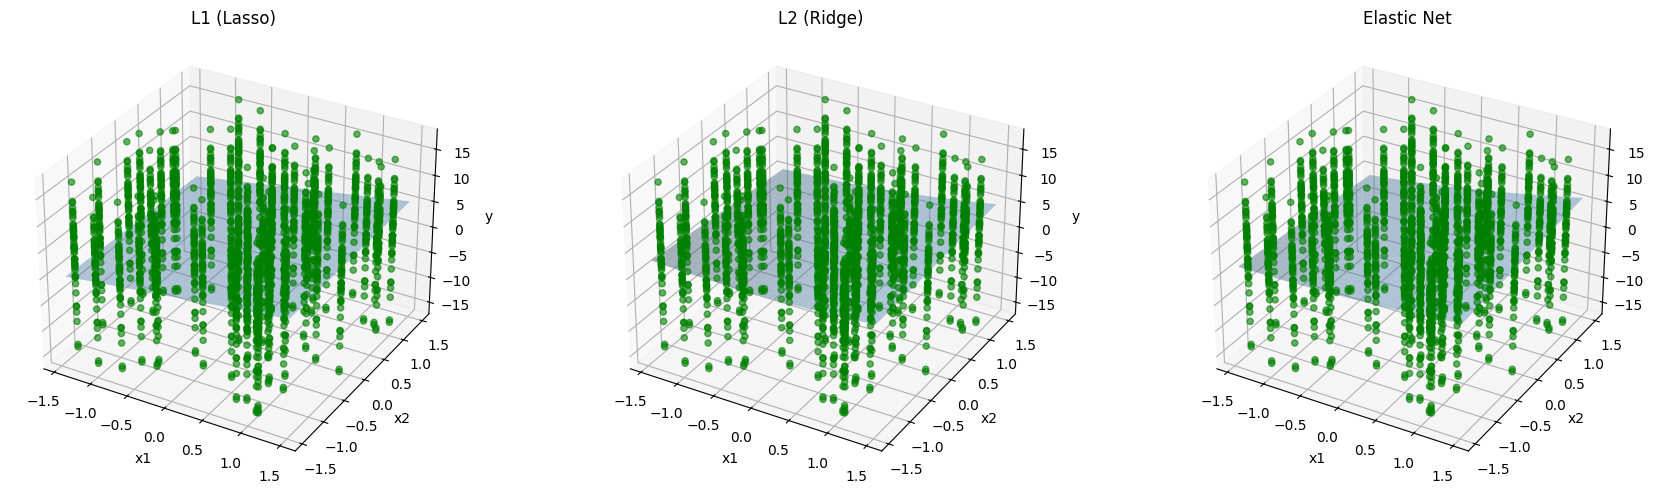

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)

# Build a smooth grid over the x1/x2 range to draw each fitted surface
x1_arr = np.array(x1)
x2_arr = np.array(x2)

x1_range = np.linspace(x1_arr.min(), x1_arr.max(), 30)
x2_range = np.linspace(x2_arr.min(), x2_arr.max(), 30)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Same feature engineering as X_poly: [x1, x2, x1^2, x1*x2]
grid_poly = np.column_stack((
    x1_grid.ravel(),
    x2_grid.ravel(),
    x1_grid.ravel()**2,
    x1_grid.ravel()*x2_grid.ravel()
))

def predict_surface(W, b):
    preds = polynomial_regression(grid_poly, W, b)
    return preds.reshape(x1_grid.shape)

models = [
    ("L1 (Lasso)", w_final, b_final),
    ("L2 (Ridge)", w_final_L2, b_final_L2),
    ("Elastic Net", w_final_elastic, b_final_elastic),
]

fig = plt.figure(figsize=(18, 5))

for i, (title, W, b) in enumerate(models, start=1):
    ax = fig.add_subplot(1, 3, i, projection='3d')

    # Actual data points
    ax.scatter(x1_arr, x2_arr, y.flatten(), color='green', alpha=0.6, label='Actual data')

    # Fitted surface
    z_surface = predict_surface(W, b)
    ax.plot_surface(x1_grid, x2_grid, z_surface, alpha=0.4, color='steelblue')

    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('y')

plt.tight_layout()
plt.show()